# AI Lab 14 — Regression & Classification Metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

---
## Exercise 1 — Regression

In [2]:
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X.flatten() + np.random.randn(100)

print("Feature values (X):")
print(X[:10])
print("\nTarget values (y):")
print(y[:10])

Feature values (X):
[[0.74908024]
 [1.90142861]
 [1.46398788]
 [1.19731697]
 [0.31203728]
 [0.31198904]
 [0.11616722]
 [1.73235229]
 [1.20223002]
 [1.41614516]]

Target values (y):
[6.33428778 9.40527849 8.48372443 5.60438199 4.71643995 5.29307969
 5.82639572 8.67878666 6.79819647 7.74667842]


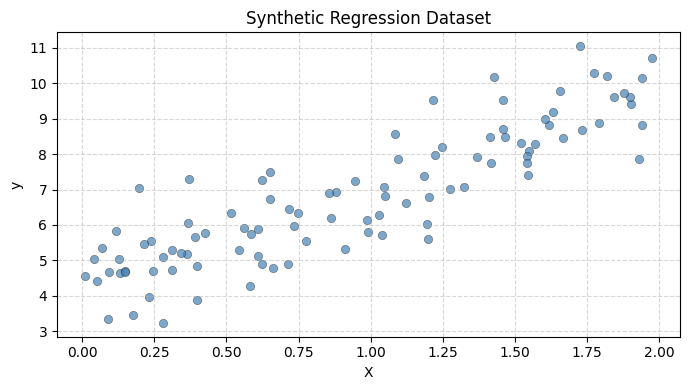

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(X, y, color='steelblue', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.title("Synthetic Regression Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Intercept : {model.intercept_:.4f}")
print(f"Coefficient: {model.coef_[0]:.4f}")

Intercept : 4.1429
Coefficient: 2.7993


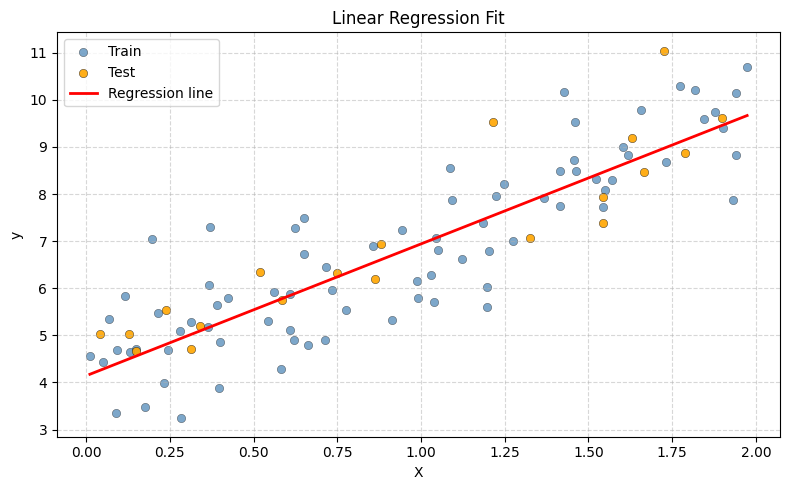

In [5]:
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='steelblue', alpha=0.7,
            edgecolors='k', linewidths=0.3, label='Train')
plt.scatter(X_test, y_test, color='orange', alpha=0.9,
            edgecolors='k', linewidths=0.3, label='Test')
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression line')
plt.title("Linear Regression Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### (1) Manual Metric Functions — NumPy only

In [6]:
def manual_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def manual_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def manual_rmse(y_true, y_pred):
    return np.sqrt(manual_mse(y_true, y_pred))

def manual_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

### (2) Scikit-learn Built-in Metrics

In [7]:
m_mae  = manual_mae(y_test, y_pred)
m_mse  = manual_mse(y_test, y_pred)
m_rmse = manual_rmse(y_test, y_pred)
m_r2   = manual_r2(y_test, y_pred)

s_mae  = mean_absolute_error(y_test, y_pred)
s_mse  = mean_squared_error(y_test, y_pred)
s_rmse = np.sqrt(s_mse)
s_r2   = r2_score(y_test, y_pred)

### (3) Side-by-Side Comparison

In [8]:
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Manual (NumPy)": [m_mae, m_mse, m_rmse, m_r2],
    "Built-in (sklearn)": [s_mae, s_mse, s_rmse, s_r2],
})
results["Match"] = results.apply(
    lambda r: "✓" if abs(r["Manual (NumPy)"] - r["Built-in (sklearn)"]) < 1e-10 else "✗",
    axis=1
)
results[["Manual (NumPy)", "Built-in (sklearn)"]] = results[
    ["Manual (NumPy)", "Built-in (sklearn)"]
].round(6)
print(results.to_string(index=False))

Metric  Manual (NumPy)  Built-in (sklearn) Match
   MAE        0.591343            0.591343     ✓
   MSE        0.653700            0.653700     ✓
  RMSE        0.808517            0.808517     ✓
    R²        0.807206            0.807206     ✓


---
## Exercise 2 — Classification (Cancer Dataset)
### 2.1 Load & Explore

In [9]:
df = pd.read_csv("cancer.csv")
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")
df = df.dropna()

print("Shape:", df.shape)
print()
print(df["diagnosis"].value_counts())
df.head()

Shape: (569, 31)

diagnosis
B    357
M    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


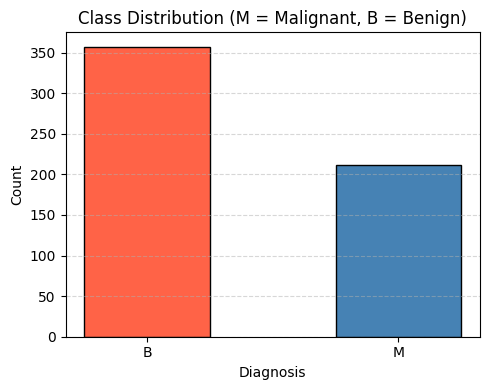

In [10]:
counts = df["diagnosis"].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(counts.index, counts.values,
        color=['tomato', 'steelblue'], edgecolor='k', width=0.5)
plt.title("Class Distribution (M = Malignant, B = Benign)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
le = LabelEncoder()
y_cancer = le.fit_transform(df["diagnosis"])
X_cancer = df.drop(columns=["diagnosis"]).values

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)
print(f"Train size: {len(X_tr)}  |  Test size: {len(X_te)}")

Class mapping: {'B': np.int64(0), 'M': np.int64(1)}
Train size: 455  |  Test size: 114


In [12]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_tr, y_tr)
y_pred_clf = clf.predict(X_te)
print("Model trained. Predictions generated.")

Model trained. Predictions generated.


### 2.2 Confusion Matrix from Scratch

In [13]:
def confusion_matrix_scratch(y_true, y_pred):
    classes = np.unique(np.concatenate([y_true, y_pred]))
    n = len(classes)
    cm = np.zeros((n, n), dtype=int)
    idx = {c: i for i, c in enumerate(classes)}
    for t, p in zip(y_true, y_pred):
        cm[idx[t]][idx[p]] += 1
    return cm, classes

cm_scratch, classes = confusion_matrix_scratch(y_te, y_pred_clf)

print("Confusion Matrix (scratch):")
print(f"Classes: {le.inverse_transform(classes)}")
print(cm_scratch)

Confusion Matrix (scratch):
Classes: ['B' 'M']
[[72  0]
 [ 3 39]]


### 2.3 Accuracy, Precision, Recall, F1 from Scratch
For binary classification: positive class = **M (Malignant) = 1**, negative class = **B (Benign) = 0**.

In [14]:
def metrics_from_cm(cm):
    TP = cm[1][1]
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    return accuracy, precision, recall, f1

acc_s, prec_s, rec_s, f1_s = metrics_from_cm(cm_scratch)

print(f"Accuracy  (scratch): {acc_s:.6f}")
print(f"Precision (scratch): {prec_s:.6f}")
print(f"Recall    (scratch): {rec_s:.6f}")
print(f"F1 Score  (scratch): {f1_s:.6f}")

Accuracy  (scratch): 0.973684


Precision (scratch): 1.000000
Recall    (scratch): 0.928571
F1 Score  (scratch): 0.962963


### 2.4 Verify with Scikit-learn Built-in Methods

In [15]:
acc_b  = accuracy_score(y_te, y_pred_clf)
prec_b = precision_score(y_te, y_pred_clf)
rec_b  = recall_score(y_te, y_pred_clf)
f1_b   = f1_score(y_te, y_pred_clf)

clf_results = pd.DataFrame({
    "Metric":     ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Scratch":    [acc_s, prec_s, rec_s, f1_s],
    "sklearn":    [acc_b, prec_b, rec_b, f1_b],
})
clf_results["Match"] = clf_results.apply(
    lambda r: "✓" if abs(r["Scratch"] - r["sklearn"]) < 1e-10 else "✗", axis=1
)
clf_results[["Scratch", "sklearn"]] = clf_results[["Scratch", "sklearn"]].round(6)
print(clf_results.to_string(index=False))

   Metric  Scratch  sklearn Match
 Accuracy 0.973684 0.973684     ✓
Precision 1.000000 1.000000     ✓
   Recall 0.928571 0.928571     ✓
 F1 Score 0.962963 0.962963     ✓


### 2.5 Confusion Matrix Visualisation

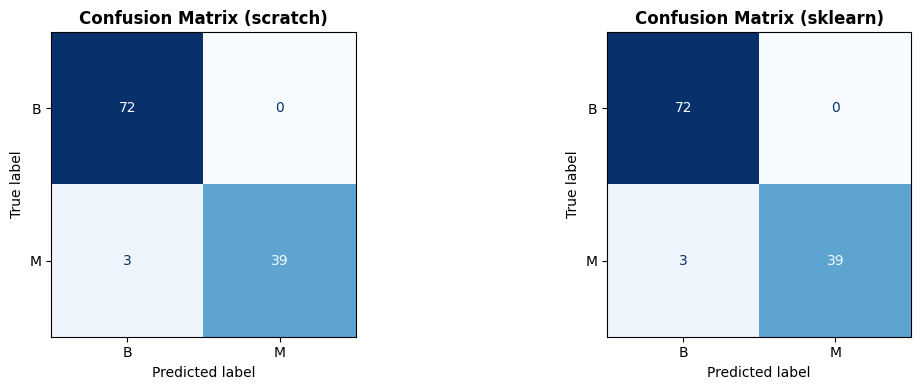

In [16]:
cm_builtin = confusion_matrix(y_te, y_pred_clf)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cm, title in zip(
    axes,
    [cm_scratch, cm_builtin],
    ["Confusion Matrix (scratch)", "Confusion Matrix (sklearn)"]
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()